In [1]:
import sys
sys.dont_write_bytecode = True
sys.path.insert(0, "..")
import numpy as np
from tqdm import tqdm
import pandas as pd
import datetime as dt
from scipy.stats import pearsonr
import pickle
import torch
import torch.nn as nn
import os
import time
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import math
from math import sqrt
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import codes.mnn_Utils as mnn
from codes.make_dataset import DatasetHist
from codes.data_utils import ips_omni_processor
import random

from codes.plot_utils import plot_losses

from codes.train_utils import cleanup

from termcolor import colored


# device = torch.device("cuda")
device = torch.device("xpu")
%load_ext autoreload
%autoreload 2

In [2]:
with open("../model_outputs_corrected/local_run/corrsM2e", "r") as f:
    corr_stat = f.read()
print(corr_stat)

base_v0_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E5_sR0.85_dA0.00e+00	-0.109163	76.550395	-0.021028	79.336735	-0.071975	76.192006	0.018765	87.760812	2



In [6]:
with open("../model_outputs/local_runs_3/tifr_runs/local_runs_3/corrsM2e", "r") as f:
    corr_stat = f.read()
print(corr_stat)

base_v0_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E10_sR0.80	-0.024038	81.263139	0.095735	82.835072	0.027022	81.600812	-0.039981	83.011539	10
base_v0_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E10_sR0.75	0.112192	81.315532	-0.090163	84.935509	0.092490	80.981204	0.067697	79.634284	10
base_v0_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E10_sR0.70	-0.065686	85.940825	0.132511	80.582611	0.051603	84.932182	0.183973	80.739821	10
base_v0_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E10_sR0.65	0.150629	80.886401	-0.010279	87.626230	0.127490	81.545504	0.138357	78.628450	10



In [3]:
def plot_paths(train_path:str, val_path:str, title:str="Training_loss", save_path:str=None, ylim:list=None):
    with open(train_path, "rb") as f:
        train_losses = pickle.load(f)
    with open(val_path, "rb") as f:
        val_losses = pickle.load(f)
    plot_losses(train_losses, val_losses, title=title, save_path=save_path, ylim=ylim)

def plot_full(full_path:str, save_path:str=None, ylim:list=None):
    list_files = os.listdir(full_path)
    # print(list_files)
    list_files = [x for x in list_files if len(x.split("_")) > 3]
    train_list = [x for x in list_files if (x.split("_")[2] == "train") & (x.split("_")[3] == "y")]
    val_list = ["_".join([z if z != "train" else "val" for z in y]) for x in train_list for y in [x.split("_")] ]
    # print(train_list)
    # print(val_list)
    for train_path, val_path in zip(train_list, val_list):
        print(train_path, val_path, sep="-----")
        if save_path is None:
            plot_paths(full_path + train_path, full_path + val_path, title=val_path, ylim=ylim)
        else:
            img_path = os.path.join(save_path, val_path)
            img_path = img_path + ".png"
            plot_paths(full_path + train_path, full_path + val_path, title=val_path, save_path=img_path, ylim=ylim)

base_v0_train_y_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E5_sR0.85_dA0.00e+00-----base_v0_val_y_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E5_sR0.85_dA0.00e+00


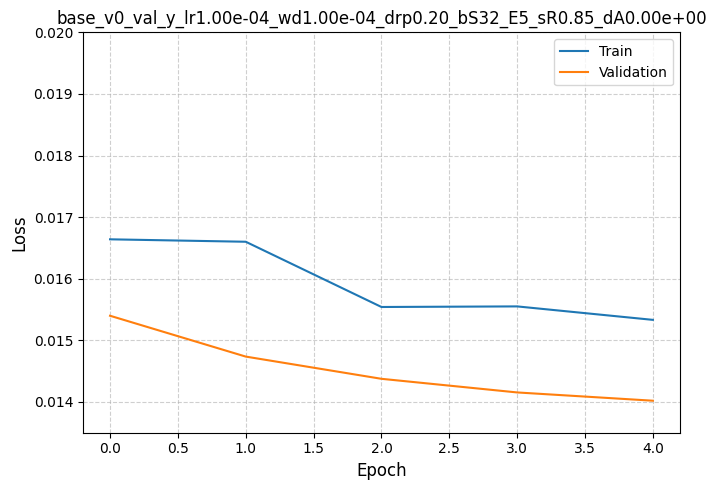

In [4]:
full_path = "../model_outputs_corrected/local_run/losses/"
# os.listdir(full_path)
plot_full(full_path, ylim=[0.0135, 0.02])

In [27]:
dropouts = [0.3, 0.2, 0.4][:1]
dropouts

[0.3]

In [ ]:
"base_v0_val_y_lr1.00e-04_wd1.00e-05_drp0.20_bS16_E10_sR0.95"
"base_v0_val_y_lr1.00e-04_wd1.00e-05_drp0.20_bS32_E10_sR0.95"
"base_v0_val_y_lr1.00e-04_wd1.00e-04_drp0.20_bS32_E10_sR0.95"
"base_v0_val_y_lr1.00e-04_wd1.00e-04_drp0.20_bS16_E10_sR0.95"